# Домашнее задание 3. VAE + NF + VAPNEV

В этом задании вам предстоит поработать с набором данных CelebA. Решение домашней работы должно быть представлено в виде .zip архива, содержащего:
- Jupyter Notebook(и) и/или модули с кодом,
- PDF-отчет, в котором необходимо описать проведённые эксперименты, а также обосновать выбор используемых методов (например, дополнительные лоссы для стабилизации, виды потоков, особенности реализации VAE и пр.).

In [1]:
# import yadisk
# def download_extract_dataset_yadisk():
#     y = yadisk.YaDisk()
#     public_url = "https://disk.yandex.ru/d/jSE5WDj3-Wllsg"
#     public_info = y.get_public_meta(public_url)
#     y.download_public(public_url, public_info['name'])

# download_extract_dataset_yadisk()

#### Настройка окружения

In [1]:
# import sys
# sys.path.append('../seminars/utils/')  # Добавляем путь к CelebADataset

import torch
from torchvision import transforms

import matplotlib.pyplot as plt
import numpy as np

from datasets.celeba import CelebADataset

# Set device
cuda = torch.cuda.is_available()
device = torch.device("cuda:6" if cuda else ("mps" if torch.backends.mps.is_available() else "cpu"))
torch.backends.cudnn.benchmark = cuda

print(f"Using device: {device}")

Using device: cuda:6


### Загрузка данных

In [2]:
# Определение трансформаций

t_normalize = lambda x: x * 2 - 1
t_invnormalize = lambda x: (x + 1) / 2

transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    t_normalize,
])

In [3]:
# Кастомный датасет CelebA, возвращающий только изображения

class CelebaCustomDataset(CelebADataset):
    def __getitem__(self, idx):
        image, _ = super().__getitem__(idx)
        return image

dataset = CelebaCustomDataset(
    transform=transform,
    root_dir='../seminars/data/celeba',
)

# Пример получения изображения
img = dataset[0]
print("Размер изображения:", img.shape)

Размер изображения: torch.Size([3, 64, 64])


### Визуализация датасета

In [4]:
def plot_img(img, transform=None):
    if transform:
        img = transform(img)
    plt.imshow(img.permute(1, 2, 0))
    plt.axis('off')

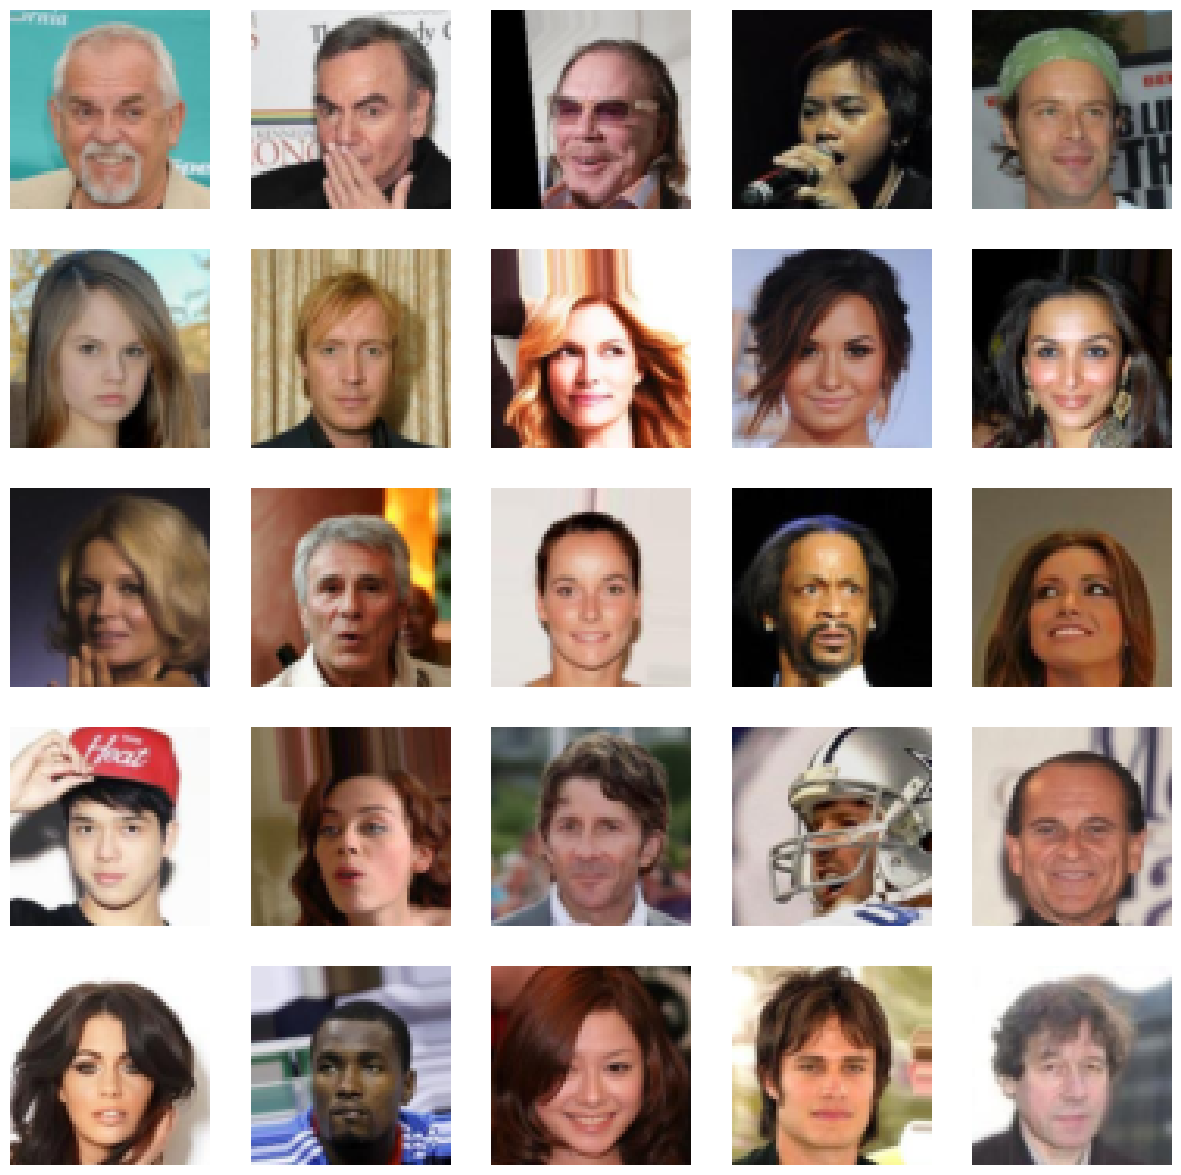

In [5]:
plt.figure(figsize=(15, 15))
for i in range(25):
    random_idx = np.random.randint(len(dataset))
    img = dataset[random_idx]
    plt.subplot(5, 5, i + 1)
    plot_img(img, t_invnormalize)
plt.show()

### Задача 1 (4/10 баллов): Построение и обучение нормального потока (Normalizing Flow) на CelebA

Необходимо обучить нормальный поток до качества, удовлетворяющего базовым порогам (точные пороги будут предоставлены позже). 

Измерьте FID и Negative Log Likelihood для оценки модели.

Внутри потока можно использовать любые компоненты: Coupling/Autoregressive/Linear слои, произвольные трансформации и т.д. Главное — реализовать их самостоятельно без копипаста.

Можно использовать как сверточные потоки (обычно дают лучшие результаты, но сложнее реализуются), так и линейные потоки (будут менее качественными), при этом можно предварительно свести изображение к вектору.

Можно использовать готовый код из репозитория курса, но рекомендуется написать свою реализацию.

In [7]:
# EPS = 1e-18

# def gaussian_log_likelihood(x_true, mu, sigma):
#     log_pdf = - torch.sum(torch.log(sigma + EPS) + 0.5 * ((x_true.unsqueeze(1) - mu) / sigma) ** 2,
#                           dim=(-1, -2, -3))  # - D / 2 * log(2 * pi)
#     return log_pdf


# def kl(q_mu, q_sigma, p_mu, p_sigma):
#     return (torch.log(p_sigma + EPS) -
#             torch.log(q_sigma + EPS) +
#             (q_sigma ** 2 + (q_mu - p_mu) ** 2) / (2 * p_sigma ** 2 + EPS) -
#             0.5).sum(-1)

#### MK 2

simple cnn

In [6]:
import torch.nn as nn
import torch

# Define CNN-based s and t networks
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 3, kernel_size=3, padding=1)
        )

    def forward(self, x):
        return self.net(x)

resnet-like cnn

In [7]:
import torch.nn as nn
import torch

class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels)
        )
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, x):
        return self.relu(x + self.net(x))

class ResNet(nn.Module):
    def __init__(self, in_channels=3, hidden_channels=64, num_blocks=3):
        super().__init__()
        layers = [nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1), 
                  nn.ReLU(inplace=True)]
        for _ in range(num_blocks):
            layers.append(ResidualBlock(hidden_channels))
        layers.append(nn.Conv2d(hidden_channels, in_channels, kernel_size=3, padding=1))
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x)


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class CouplingLayer(nn.Module):
    def __init__(self, mask, nets, nett):
        super().__init__()
        self.mask = nn.Parameter(mask, requires_grad=False)
        self.scale_net = nets()
        self.trans_net = nett()

    def forward(self, x):
        x_masked = x * self.mask
        s = self.scale_net(x_masked) * (1 - self.mask)
        t = self.trans_net(x_masked) * (1 - self.mask)
        z = x_masked + (1 - self.mask) * (x * torch.exp(s) + t)
        log_det_J = s.sum(dim=(1, 2, 3))
        return z, log_det_J

    def inverse(self, z):
        z_masked = z * self.mask
        s = self.scale_net(z_masked) * (1 - self.mask)

        # print("DEBUG", torch.isnan(s).any())
        t = self.trans_net(z_masked) * (1 - self.mask)
        x = (1 - self.mask) * (z - t) * torch.exp(-s) + z_masked
        log_det_J = -s.sum(dim=(1, 2, 3))
        return x, log_det_J

class RealNVP(nn.Module):
    def __init__(self, nets, nett, masks, prior):
        super().__init__()
        self.prior = prior
        self.coupling_layers = nn.ModuleList([CouplingLayer(mask, nets, nett) for mask in masks])

    def f(self, x):
        log_det_J = x.new_zeros(x.shape[0]).to(device)
        z = x
        for layer in self.coupling_layers:
            z, ldj = layer.inverse(z)
            log_det_J += ldj
        return z, log_det_J

    def g(self, z):
        x = z
        for layer in reversed(self.coupling_layers):
            x, _ = layer.forward(x)
        return x

    def log_prob(self, x):
        z, log_det_J = self.f(x)
        return self.prior.log_prob(z).sum(dim=(1, 2, 3)) + log_det_J

    def sample(self, batch_size):
        z = self.prior.sample((batch_size,))
        return self.g(z)



# Generate checkerboard masks
def create_masks():
    masks = []
    for i in range(4):  # More masks improve expressivity
        mask = np.random.randint(0, 2, size=(3, 64, 64)).astype(np.float32)
        masks.append(torch.tensor(mask))
    return masks



In [9]:

# Define prior
prior = torch.distributions.Normal(torch.zeros((3, 64, 64)).to(device), torch.ones((3, 64, 64)).to(device))

# Initialize model
masks = create_masks()
flow = RealNVP(SimpleCNN, SimpleCNN, masks, prior).to(device)

In [10]:
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=512,
    num_workers=4,
    pin_memory=True if device.type == 'cuda' else False,
    shuffle=True
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9296999..4.397521].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.3508267..3.4021537].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.243857..3.3816776].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.460388..4.9233503].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.2251067..3.295801].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.2390246..2.5778012].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.6163445..4

Epoch 43/100 | Loss: -11812.9053


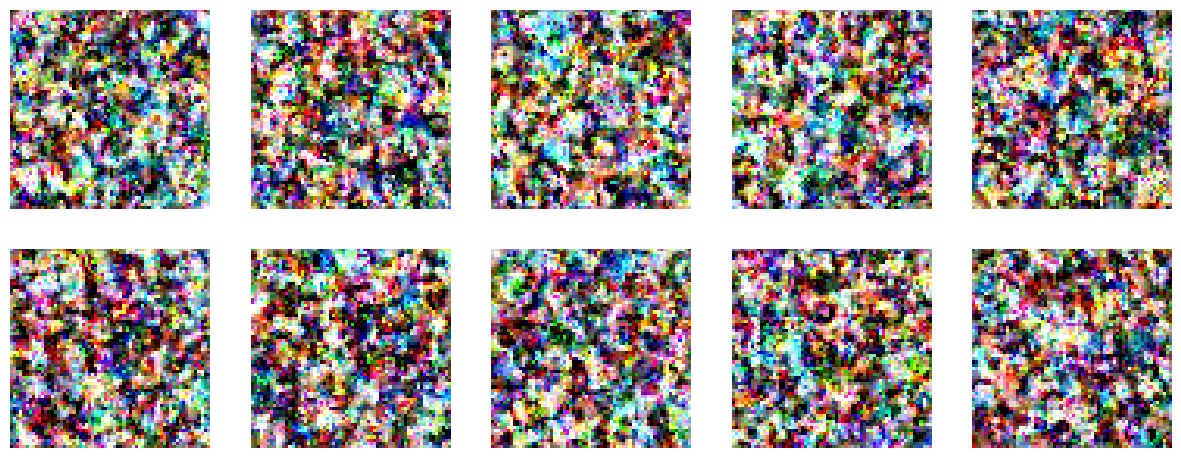

Epoch 44/100 | Batch 0/396 | Loss: -11681.2344


In [ ]:
import torch
import torch.optim as optim
from IPython.display import clear_output

optimizer = optim.Adam(flow.parameters(), lr=1e-4)
num_epochs = 100

for epoch in range(num_epochs):

    flow.train()
    for batch_idx, x in enumerate(dataloader):
        x = x.to(device)
        optimizer.zero_grad()
        loss = -flow.log_prob(x).mean()  # Negative log likelihood
        loss.backward()
        torch.nn.utils.clip_grad_norm_(flow.parameters(), max_norm=1.0)
        optimizer.step()

        if batch_idx % 100 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | Batch {batch_idx}/{len(dataloader)} | Loss: {loss.item():.4f}")


    clear_output()
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {loss.item():.4f}")
    # save
    if epoch % 30 == 0 and epoch > 0:
        torch.save(flow.state_dict(), f"./flow_mk1{epoch}.pth")
    
    # sample
    num_samples = 10
    flow.eval()
    with torch.no_grad():
        samples = flow.sample(num_samples)


    plt.figure(figsize=(15, 15))
    for i in range(num_samples):
        img = samples[i].detach().cpu()
        plt.subplot(5, 5, i + 1)
        plot_img(img, t_invnormalize)
    plt.show()



In [ ]:
torch.save(flow.state_dict(), "./flow_mk1_last.pth")

### MK 1

### MK 1

In [ ]:
from torch import nn

class MLP(nn.Module):
    """ a simple 4-layer MLP """

    def __init__(self, nin, nout, nh):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(nin, nh),
            nn.LeakyReLU(0.2),
            nn.Linear(nh, nh),
            nn.LeakyReLU(0.2),
            nn.Linear(nh, nh),
            nn.LeakyReLU(0.2),
            nn.Linear(nh, nout),
        )
    def forward(self, x):
        return self.net(x)

class AffineConstantFlow(nn.Module):
    """ 
    Scales + Shifts the flow by (learned) constants per dimension.
    In NICE paper there is a Scaling layer which is a special case of this where t is None
    """
    def __init__(self, dim, scale=True, shift=True):
        super().__init__()
        self.s = nn.Parameter(torch.randn(1, dim, requires_grad=True)) if scale else None
        self.t = nn.Parameter(torch.randn(1, dim, requires_grad=True)) if shift else None
        
    def forward(self, x):
        s = self.s if self.s is not None else x.new_zeros(x.size())
        t = self.t if self.t is not None else x.new_zeros(x.size())
        z = x * torch.exp(s) + t
        log_det = torch.sum(s, dim=1)
        return z, log_det
    
    def backward(self, z):
        s = self.s if self.s is not None else z.new_zeros(z.size())
        t = self.t if self.t is not None else z.new_zeros(z.size())
        x = (z - t) * torch.exp(-s)
        log_det = torch.sum(-s, dim=1)
        return x, log_det


class ActNorm(AffineConstantFlow):
    """
    Really an AffineConstantFlow but with a data-dependent initialization,
    where on the very first batch we clever initialize the s,t so that the output
    is unit gaussian. As described in Glow paper.
    """
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.data_dep_init_done = False
    
    def forward(self, x):
        # first batch is used for init
        if not self.data_dep_init_done:
            assert self.s is not None and self.t is not None # for now
            self.s.data = (-torch.log(x.std(dim=0, keepdim=True))).detach()
            self.t.data = (-(x * torch.exp(self.s)).mean(dim=0, keepdim=True)).detach()
            self.data_dep_init_done = True
        return super().forward(x)


class AffineHalfFlow(nn.Module):
    """
    As seen in RealNVP, affine autoregressive flow (z = x * exp(s) + t), where half of the 
    dimensions in x are linearly scaled/transfromed as a function of the other half.
    Which half is which is determined by the parity bit.
    - RealNVP both scales and shifts (default)
    - NICE only shifts
    """
    def __init__(self, dim, parity, net_class=MLP, nh=24, scale=True, shift=True):
        super().__init__()
        self.dim = dim
        self.parity = parity
        self.s_cond = lambda x: x.new_zeros(x.size(0), self.dim // 2)
        self.t_cond = lambda x: x.new_zeros(x.size(0), self.dim // 2)
        if scale:
            self.s_cond = net_class(self.dim // 2, self.dim // 2, nh)
        if shift:
            self.t_cond = net_class(self.dim // 2, self.dim // 2, nh)
        
    def forward(self, x):
        x0, x1 = x[:,::2], x[:,1::2]
        if self.parity:
            x0, x1 = x1, x0
        s = self.s_cond(x0)
        t = self.t_cond(x0)
        z0 = x0 # untouched half
        z1 = torch.exp(s) * x1 + t # transform this half as a function of the other
        if self.parity:
            z0, z1 = z1, z0
        z = torch.cat([z0, z1], dim=1)
        log_det = torch.sum(s, dim=1)
        return z, log_det
    
    def backward(self, z):
        z0, z1 = z[:,::2], z[:,1::2]
        if self.parity:
            z0, z1 = z1, z0
        s = self.s_cond(z0)
        t = self.t_cond(z0)
        x0 = z0 # this was the same
        x1 = (z1 - t) * torch.exp(-s) # reverse the transform on this half
        if self.parity:
            x0, x1 = x1, x0
        x = torch.cat([x0, x1], dim=1)
        log_det = torch.sum(-s, dim=1)
        return x, log_det

# ------------------------------------------------------------------------

class NormalizingFlow(nn.Module):
    """ A sequence of Normalizing Flows is a Normalizing Flow """

    def __init__(self, flows):
        super().__init__()
        self.flows = nn.ModuleList(flows)

    def forward(self, x):
        log_det = torch.zeros(x.size(0), device=device)    # batch size
        zs = [x]
        for flow in self.flows:
            x, ld = flow.forward(x)
            log_det += ld
            zs.append(x)
        return zs, log_det

    def backward(self, z):
        m, _ = z.shape
        log_det = torch.zeros(m, device=device)
        xs = [z]
        for flow in self.flows[::-1]:
            z, ld = flow.backward(z)
            log_det += ld
            xs.append(z)
        return xs, log_det

class NormalizingFlowModel(nn.Module):
    """ A Normalizing Flow Model is a (prior, flow) pair """
    
    def __init__(self, prior, flows):
        super().__init__()
        self.prior = prior
        self.flow = NormalizingFlow(flows)
    
    def forward(self, x):
        zs, log_det = self.flow.forward(x)
        prior_logprob = self.prior.log_prob(zs[-1]).view(x.size(0), -1).sum(1)
        return zs, prior_logprob, log_det

    def backward(self, z):
        xs, log_det = self.flow.backward(z)
        return xs, log_det
    
    def sample(self, num_samples):
        z = self.prior.sample((num_samples,))
        xs, _ = self.flow.backward(z)
        return xs


In [ ]:
from munch import Munch

flow_conf = Munch()

flow_conf.batch_size = 128
flow_conf.dim = 3 * 64 * 64
flow_conf.nh = 1024

flow_conf.flows_count = 10

flow_conf.save_every = 30


In [ ]:
import itertools
from torch.distributions import MultivariateNormal

flows = [AffineHalfFlow(dim=flow_conf.dim, parity=i%2, nh=flow_conf.nh) for i in range(flow_conf.flows_count)]
norms = [ActNorm(dim=flow_conf.dim) for _ in flows]
flows = list(itertools.chain(*zip(norms, flows)))

prior = MultivariateNormal(torch.zeros(flow_conf.dim).to(device=device), 
                           torch.eye(flow_conf.dim).to(device=device))

model = NormalizingFlowModel(prior, flows).to(device)

In [ ]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
# scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, 0.95, verbose=True)

print("number of params: ", sum(p.numel() for p in model.parameters()))

number of params:  294031360


In [ ]:
def flatten_images(images):
    # images shape: (batch, 3, 64, 64)
    return images.view(images.size(0), -1)

In [ ]:
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=flow_conf.batch_size,
    num_workers=4,
    pin_memory=True if device.type == 'cuda' else False,
    shuffle=True
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0234623..2.3851957].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5017412..2.9333594].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.492464..3.4748046].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3119893..2.406228].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3999873..3.559169].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7738316..2.903598].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99862194..

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0532182..5.375348].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6975543..3.1411128].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2670882..2.6093583].


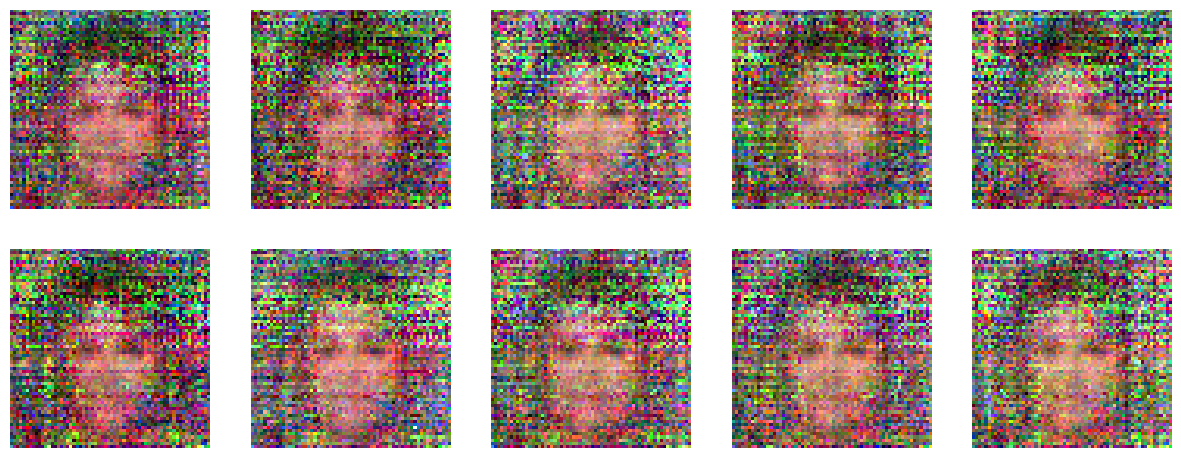

Epoch: 9, Loss: -926474.75


In [ ]:
from IPython.display import clear_output

n_epoches = 10
model.train()

for epoch in range(n_epoches):
    model.train()
    for step, batch in enumerate(dataloader):
        

        model.zero_grad()

        zs, prior_logprob, log_det = model(flatten_images(batch).to(device))
        logprob = prior_logprob + log_det
        loss = -torch.sum(logprob) # NLL

        
        loss.backward()
        optimizer.step()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)


    #### sample
    model.eval()
    num_samples = 10
    samples = model.sample(num_samples)[-1].view(num_samples, 3, 64, 64)

    clear_output()
    plt.figure(figsize=(15, 15))
    for i in range(num_samples):
        img = samples[i].detach().cpu()
        plt.subplot(5, 5, i + 1)
        plot_img(img, t_invnormalize)
    plt.show()
    ####


    if epoch % flow_conf.save_every == 0 and epoch > 0:
        torch.save(model.state_dict(), f"./norm_flow_{epoch}.pth")
        
    print(f'Epoch: {epoch}, Loss: {loss.item():.2f}')


In [6]:
from torch import nn

class MLP(nn.Module):
    """ a simple 4-layer MLP """

    def __init__(self, nin, nout, nh):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(nin, nh),
            nn.LeakyReLU(0.2),
            nn.Linear(nh, nh),
            nn.LeakyReLU(0.2),
            nn.Linear(nh, nh),
            nn.LeakyReLU(0.2),
            nn.Linear(nh, nout),
        )
    def forward(self, x):
        return self.net(x)

class AffineConstantFlow(nn.Module):
    """ 
    Scales + Shifts the flow by (learned) constants per dimension.
    In NICE paper there is a Scaling layer which is a special case of this where t is None
    """
    def __init__(self, dim, scale=True, shift=True):
        super().__init__()
        self.s = nn.Parameter(torch.randn(1, dim, requires_grad=True)) if scale else None
        self.t = nn.Parameter(torch.randn(1, dim, requires_grad=True)) if shift else None
        
    def forward(self, x):
        s = self.s if self.s is not None else x.new_zeros(x.size())
        t = self.t if self.t is not None else x.new_zeros(x.size())
        z = x * torch.exp(s) + t
        log_det = torch.sum(s, dim=1)
        return z, log_det
    
    def backward(self, z):
        s = self.s if self.s is not None else z.new_zeros(z.size())
        t = self.t if self.t is not None else z.new_zeros(z.size())
        x = (z - t) * torch.exp(-s)
        log_det = torch.sum(-s, dim=1)
        return x, log_det


class ActNorm(AffineConstantFlow):
    """
    Really an AffineConstantFlow but with a data-dependent initialization,
    where on the very first batch we clever initialize the s,t so that the output
    is unit gaussian. As described in Glow paper.
    """
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.data_dep_init_done = False
    
    def forward(self, x):
        # first batch is used for init
        if not self.data_dep_init_done:
            assert self.s is not None and self.t is not None # for now
            self.s.data = (-torch.log(x.std(dim=0, keepdim=True))).detach()
            self.t.data = (-(x * torch.exp(self.s)).mean(dim=0, keepdim=True)).detach()
            self.data_dep_init_done = True
        return super().forward(x)


class AffineHalfFlow(nn.Module):
    """
    As seen in RealNVP, affine autoregressive flow (z = x * exp(s) + t), where half of the 
    dimensions in x are linearly scaled/transfromed as a function of the other half.
    Which half is which is determined by the parity bit.
    - RealNVP both scales and shifts (default)
    - NICE only shifts
    """
    def __init__(self, dim, parity, net_class=MLP, nh=24, scale=True, shift=True):
        super().__init__()
        self.dim = dim
        self.parity = parity
        self.s_cond = lambda x: x.new_zeros(x.size(0), self.dim // 2)
        self.t_cond = lambda x: x.new_zeros(x.size(0), self.dim // 2)
        if scale:
            self.s_cond = net_class(self.dim // 2, self.dim // 2, nh)
        if shift:
            self.t_cond = net_class(self.dim // 2, self.dim // 2, nh)
        
    def forward(self, x):
        x0, x1 = x[:,::2], x[:,1::2]
        if self.parity:
            x0, x1 = x1, x0
        s = self.s_cond(x0)
        t = self.t_cond(x0)
        z0 = x0 # untouched half
        z1 = torch.exp(s) * x1 + t # transform this half as a function of the other
        if self.parity:
            z0, z1 = z1, z0
        z = torch.cat([z0, z1], dim=1)
        log_det = torch.sum(s, dim=1)
        return z, log_det
    
    def backward(self, z):
        z0, z1 = z[:,::2], z[:,1::2]
        if self.parity:
            z0, z1 = z1, z0
        s = self.s_cond(z0)
        t = self.t_cond(z0)
        x0 = z0 # this was the same
        x1 = (z1 - t) * torch.exp(-s) # reverse the transform on this half
        if self.parity:
            x0, x1 = x1, x0
        x = torch.cat([x0, x1], dim=1)
        log_det = torch.sum(-s, dim=1)
        return x, log_det

# ------------------------------------------------------------------------

class NormalizingFlow(nn.Module):
    """ A sequence of Normalizing Flows is a Normalizing Flow """

    def __init__(self, flows):
        super().__init__()
        self.flows = nn.ModuleList(flows)

    def forward(self, x):
        log_det = torch.zeros(x.size(0), device=device)    # batch size
        zs = [x]
        for flow in self.flows:
            x, ld = flow.forward(x)
            log_det += ld
            zs.append(x)
        return zs, log_det

    def backward(self, z):
        m, _ = z.shape
        log_det = torch.zeros(m, device=device)
        xs = [z]
        for flow in self.flows[::-1]:
            z, ld = flow.backward(z)
            log_det += ld
            xs.append(z)
        return xs, log_det

class NormalizingFlowModel(nn.Module):
    """ A Normalizing Flow Model is a (prior, flow) pair """
    
    def __init__(self, prior, flows):
        super().__init__()
        self.prior = prior
        self.flow = NormalizingFlow(flows)
    
    def forward(self, x):
        zs, log_det = self.flow.forward(x)
        prior_logprob = self.prior.log_prob(zs[-1]).view(x.size(0), -1).sum(1)
        return zs, prior_logprob, log_det

    def backward(self, z):
        xs, log_det = self.flow.backward(z)
        return xs, log_det
    
    def sample(self, num_samples):
        z = self.prior.sample((num_samples,))
        xs, _ = self.flow.backward(z)
        return xs


In [7]:
from munch import Munch

flow_conf = Munch()

flow_conf.batch_size = 128
flow_conf.dim = 3 * 64 * 64
flow_conf.nh = 1024

flow_conf.flows_count = 10

flow_conf.save_every = 30


In [8]:
import itertools
from torch.distributions import MultivariateNormal

flows = [AffineHalfFlow(dim=flow_conf.dim, parity=i%2, nh=flow_conf.nh) for i in range(flow_conf.flows_count)]
norms = [ActNorm(dim=flow_conf.dim) for _ in flows]
flows = list(itertools.chain(*zip(norms, flows)))

prior = MultivariateNormal(torch.zeros(flow_conf.dim).to(device=device), 
                           torch.eye(flow_conf.dim).to(device=device))

model = NormalizingFlowModel(prior, flows).to(device)

In [9]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
# scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, 0.95, verbose=True)

print("number of params: ", sum(p.numel() for p in model.parameters()))

number of params:  294031360


In [10]:
def flatten_images(images):
    # images shape: (batch, 3, 64, 64)
    return images.view(images.size(0), -1)

In [11]:
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=flow_conf.batch_size,
    num_workers=4,
    pin_memory=True if device.type == 'cuda' else False,
    shuffle=True
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0234623..2.3851957].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5017412..2.9333594].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.492464..3.4748046].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3119893..2.406228].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3999873..3.559169].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7738316..2.903598].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99862194..

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0532182..5.375348].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6975543..3.1411128].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2670882..2.6093583].


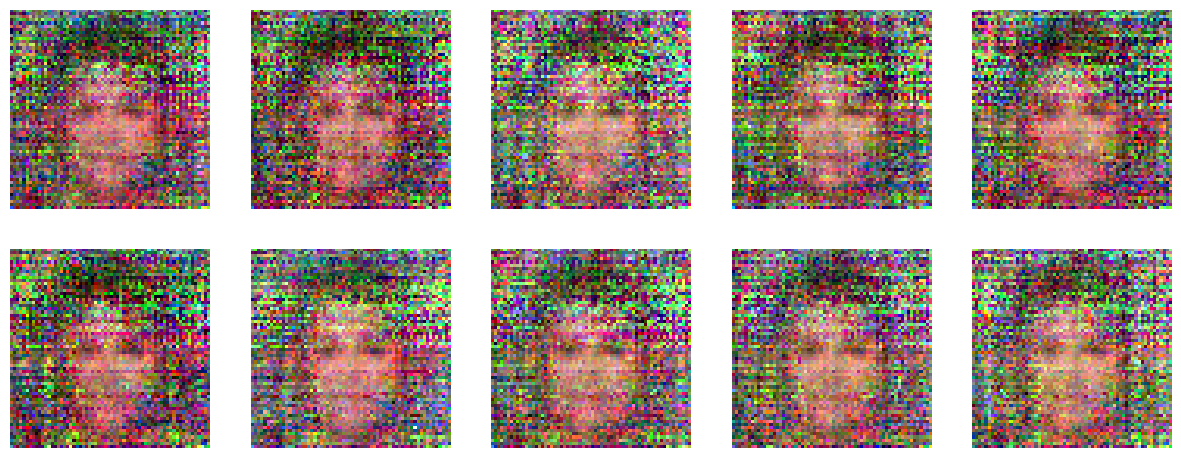

Epoch: 9, Loss: -926474.75


In [12]:
from IPython.display import clear_output

n_epoches = 10
model.train()

for epoch in range(n_epoches):
    model.train()
    for step, batch in enumerate(dataloader):
        

        model.zero_grad()

        zs, prior_logprob, log_det = model(flatten_images(batch).to(device))
        logprob = prior_logprob + log_det
        loss = -torch.sum(logprob) # NLL

        
        loss.backward()
        optimizer.step()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)


    #### sample
    model.eval()
    num_samples = 10
    samples = model.sample(num_samples)[-1].view(num_samples, 3, 64, 64)

    clear_output()
    plt.figure(figsize=(15, 15))
    for i in range(num_samples):
        img = samples[i].detach().cpu()
        plt.subplot(5, 5, i + 1)
        plot_img(img, t_invnormalize)
    plt.show()
    ####


    if epoch % flow_conf.save_every == 0 and epoch > 0:
        torch.save(model.state_dict(), f"./norm_flow_{epoch}.pth")
        
    print(f'Epoch: {epoch}, Loss: {loss.item():.2f}')


### Задача 2 (2/10 баллов): Построение и обучение VAE на CelebA

Обучите вариационный автоэнкодер (VAE) до достижения приемлемого качества генерации. Измерьте FID и сохраните результаты для дальнейшего сравнения.

Можно использовать готовые решения из репозитория курса, но предпочтительно написать свою реализацию.

In [ ]:
torch.cuda.empty_cache()

In [ ]:
from munch import Munch

vae_args = Munch()

vae_args.batch_size = 1024
vae_args.latent_dim = 100


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvVAE64(nn.Module):
    def __init__(self, args: Munch):
        super().__init__()
        # Encoder
        self.model_args = args
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),  # 64x64 -> 32x32
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 32x32 -> 16x16
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 16x16 -> 8x8
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),  # 8x8 -> 4x4
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(256 * 4 * 4, args.latent_dim)
        self.fc_logvar = nn.Linear(256 * 4 * 4, args.latent_dim)
        self.fc_decode = nn.Linear(args.latent_dim, 256 * 4 * 4)
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # 4x4 -> 8x8
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 8x8 -> 16x16
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 16x16 -> 32x32
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),  # 32x32 -> 64x64
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(z.size(0), 256, 4, 4)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

    def sample_latent(self, mu, sigma, K=1):
        """
        Generate samples from Gaussians with diagonal covariance matrices in latent space.
        Input: mu, Tensor of shape n x d - mean vectors for n Gaussians.
        Input: sigma, Tensor of shape n x d - standard deviation vectors
               for n Gaussians.
        Input: K, int - number of samples from each Gaussian.
        Return: Tensor of shape n x K x d.
        """
        epsilon = torch.randn((mu.shape[0], K, mu.shape[1])).type_as(mu)
        sample = mu.unsqueeze(1) + sigma.unsqueeze(1) * epsilon
        return sample

    def prior_distr(self, x):
        """
        Generate prior distribution over z.
        Note that sigma is positive by design of neural network.
        Input: x, Tensor of shape n x D.
        Return: tuple(Tensor, Tensor),
                Each Tensor is a matrix of shape n x d.
                The first one is mu, the second one is sigma.
        """
        mu = torch.zeros((x.shape[0], self.latent_dim)).type_as(x)
        sigma = torch.ones((x.shape[0], self.latent_dim)).type_as(x)
        return mu, sigma

    @torch.no_grad()
    def generate_samples(self, device, num_samples=1):
        """
        Generate samples from the model.
        Input: num_samples, int - number of samples to generate.
        Return: Tensor of shape num_samples x D.
        """
        mu, sigma = self.prior_distr(torch.empty((1, self.latent_dim), device=device, dtype=torch.float))
        z = self.sample_latent(mu, sigma, K=num_samples)
        samples, _ = self.generative_distr(z)
        return samples.squeeze(0)

    def validation_step(
            self,
            batch: tuple[torch.Tensor, torch.Tensor],
            batch_idx: int
    ):
        images, labels = batch
        reconstructions, _ = self.forward(images)
        reconstructions.squeeze_(1)
        # if batch_idx == 0:
        #     return {
        #         'real images': images,
        #         # 'real labels': labels,
        #     }
        # return {
        #     'real images': None,
        #     # 'real labels': None
        # }


Обучение

In [ ]:
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=vae_args.batch_size,
    num_workers=4,
    pin_memory=True if device.type == 'cuda' else False,
    shuffle=True
)

In [ ]:
import torch.optim as optim

def loss_function(recon_x, x, mean, logvar, beta=1.0):

    batch_size = recon_x.shape[0]

    mse_loss = F.mse_loss(recon_x.view(batch_size, -1), x.view(batch_size, -1), reduction='sum') / batch_size

    kld_loss = -0.5 * torch.sum(1 + logvar - mean.pow(2) - torch.clamp(logvar.exp(), min=1e-8)) / batch_size
    kld_loss *= beta

    return mse_loss + kld_loss


device = torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')
model = ConvVAE64(vae_args).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print("using device", device)

using device cuda:2


In [ ]:
def train(epoch):
    model.train()
    train_loss = 0
    for batch_idx, data in enumerate(dataloader):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        if batch_idx % 100 == 0:
            print(f'Epoch {epoch} [{batch_idx * len(data)}/{len(dataloader.dataset)}] Loss: {loss.item() / len(data):.6f}')
    print(f'====> Epoch {epoch} Average loss: {train_loss / len(dataloader.dataset):.4f}')

# for epoch in range(1, 11):
#     train(epoch)

In [ ]:
# torch.save(model.state_dict(), "./vae64.pth")

In [ ]:
model.load_state_dict(torch.load("./vae64.pth"))

<All keys matched successfully>

In [ ]:
real_images = torch.stack([dataset[i] for i in range(5)], dim=0)
reconstructions, _, _= model.cpu()(real_images)

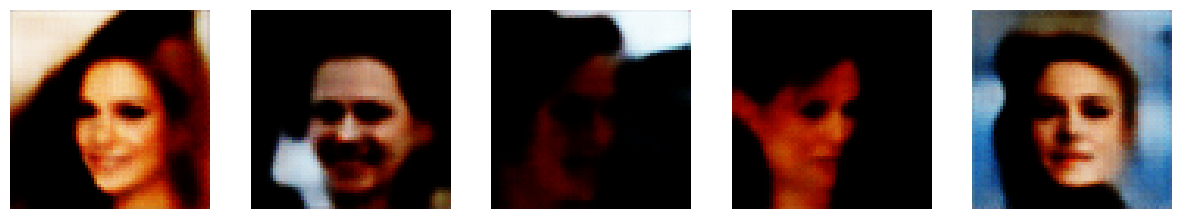

In [ ]:
plt.figure(figsize=(15, 15))
for i in range(5):
    img = reconstructions[i].detach().cpu()
    plt.subplot(5, 5, i + 1)
    plot_img(img)
plt.show()

FID

In [ ]:
from utils import FidScore


def compute_fid(vae: ConvVAE64, num_samples=1000):
    vae.eval()
    real_images = torch.stack([dataset[i] for i in range(num_samples)], dim=0)
    reconstructions, _, _= vae(real_images)
    fid = FidScore()
    fid(real_images, reconstructions)
    return fid.compute()

In [ ]:
fid = compute_fid(model.cpu(), 5)

/home/byzovti/.conda/envs/genmod0/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/byzovti/.conda/envs/genmod0/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### Задача 3 (6/10 баллов)

#### Задача 3.1 (4/10 баллов): Построение и обучение VAPNEV на CelebA

Изучите статью [VAPNEV](https://arxiv.org/pdf/1611.05209.pdf), реализуйте и обучите модель до качества, удовлетворяющего базовым порогам (точные пороги будут предоставлены позже). Измерьте FID и сохраните результаты.

#### Задача 3.2 (2/10 баллов): Построение и обучение conditional VAPNEV на CelebA

Реализуйте условный (conditional) вариант VAPNEV. Подробности можно найти в описании задачи и в статье.

In [ ]:
# TODO: Реализуйте VAPNEV и conditional VAPNEV для CelebA.

### Задача 4 (1/10 баллов): Анализ

Проведите анализ латентного пространства и оцените качество генерации:
1. Определите, у какой модели лучше интерполируется латентное пространство.
2. Попробуйте взять внешнее изображение (не из CelebA), отобразить его в латентное пространство и найдите ближайшие по значению векторы.
3. Продемонстрируйте самый интересный (или забавный) результат генерации, который у вас получался.

In [ ]:
# TODO: Добавьте код для анализа латентного пространства и демонстрации результатов.

### Задача 0: Отчет

Для получения полного балла по каждому пункту задания необходимо включить в отчет (предоставляемый отдельно в формате PDF) примеры генераций моделей. 

Сравните результаты различных моделей, постарайтесь объяснить, почему одни подходы работают лучше других.